# Build Negative Samples for a Dataset
Most peptide datasets have limited or missing negative samples. This notebook demonstrates the **Biologically Informed and Distribution-Controlled Negative Sampling (BDNegSamp)** workflow used in our paper.

We construct a candidate negative pool from two sources:
1. Experimentally active sequences from other datasets.
2. UniRef sequences as a fallback source when the active pool is too small.

Key steps for canonical peptides:
1. Build a negative pool from datasets that are biologically unrelated to the current target task.
2. If the pool is too small (default: smaller than 10x positive set size), supplement from UniRef.
3. Remove potentially related sequences and reduce redundancy in the pool.
4. Remove candidates highly similar to current positive samples.
5. Sample negatives so that distributions of `length`, `charge`, and `hydrophobicity` are close to positives.
6. Evaluate the sampling quality and merge positives and negatives into the final dataset.

Additional steps for non-canonical peptides:
1. Convert non-canonical positives to canonical peptides (for example with `pepbenchmark.convert.Helm2Fasta`) and run the same workflow.
2. Convert sampled canonical negatives back to non-canonical forms with the trained generator.

In [ ]:
import pandas as pd
from collections import Counter


def analyze_length_distribution(pos_df: pd.DataFrame, pool: list) -> pd.DataFrame:
    """Summarize sequence length distribution for positives and pool.

    Returns a DataFrame with columns:
        length, pos_count, pool_count, ratio
    where ratio = pool_count / pos_count.
    """
    pos_counts = pos_df["sequence"].apply(len).value_counts().sort_index()
    pool_counts = Counter(len(seq) for seq in pool)

    records = []
    for length in sorted(set(pos_counts.index) | set(pool_counts.keys())):
        pos_count = int(pos_counts.get(length, 0))
        pool_count = int(pool_counts.get(length, 0))
        ratio = pool_count / pos_count if pos_count > 0 else float("nan")
        records.append(
            {
                "length": int(length),
                "pos_count": pos_count,
                "pool_count": pool_count,
                "ratio": ratio,
            }
        )

    return pd.DataFrame(records)


def supplement_pool(length_df: pd.DataFrame, df: pd.DataFrame, times: int, pool_manager):
    """Supplement the sampling pool by length bins until minimum coverage is reached.

    For each length, the target pool size is `times * pos_count`.
    New samples are drawn from `df` while avoiding duplicates already in the pool.

    Returns:
        pd.DataFrame: Newly sampled sequences used for supplementation.
    """
    df = df.copy()
    df["length"] = df["sequence"].apply(len)

    existing_set = set(pool_manager.get_sampling_pool())
    sampled_dfs = []
    supplement_log = []

    for _, row in length_df.iterrows():
        length = int(row["length"])
        pos_count = int(row["pos_count"])
        pool_count = int(row["pool_count"])

        if pos_count == 0:
            continue

        required = int(pos_count * times)
        if pool_count >= required:
            continue

        need_extra = required - pool_count
        group = df[(df["length"] == length) & (~df["sequence"].isin(existing_set))]

        if len(group) == 0:
            print(f"[Warning] No available new sequences for length={length}.")
            continue

        n_to_sample = int(min(len(group), need_extra))
        if n_to_sample <= 0:
            continue

        sampled = group.sample(n=n_to_sample, random_state=42, replace=False)
        sampled_dfs.append(sampled)
        existing_set.update(sampled["sequence"].tolist())
        supplement_log.append((length, n_to_sample, required, len(group)))

    if supplement_log:
        print("\n=== Supplement summary ===")
        for length, added, required, available in supplement_log:
            print(
                f"length={length}: target={required}, added={added}, available={available}"
            )
    else:
        print("\nNo supplementation needed; pool already meets the minimum multiplier.")

    if sampled_dfs:
        sampled_dataset = pd.concat(sampled_dfs).reset_index(drop=True)
        pool_manager.add_sequences(sequences=sampled_dataset["sequence"].tolist())
        print(f"\nFinal pool size: {pool_manager.get_pool_size()}")
        return sampled_dataset

    return pd.DataFrame(columns=df.columns)

In [ ]:
import os
import pandas as pd
from pepbenchmark.neg_sampler.neg_meta import NEG_POOL_MAP

dataset_name = "dppiv_inhibitors"

# Load positive samples; Download PebBenchData_raw from https://huggingface.co/datasets/jiahuizhang/PepBenchData_raw
# put it in the root directory of this repo, and update NEG_POOL_MAP if necessary.
pos_path = os.path.join(
    os.path.dirname(NEG_POOL_MAP[dataset_name]["pos_path"]),
    "pos_filter_id_0.9_cov_f0.9.csv",
)


pos_sequences = pd.read_csv(pos_path)
pos_seq = pos_sequences["sequence"].tolist()
print(f"Positive sample count: {len(pos_seq)}")

Positive sample count: 634


In [ ]:
# Sample negatives
from pepbenchmark.neg_sampler.neg_meta import EXCLUSIVE_MAP, INCLUSIVE_MAP
from pepbenchmark.neg_sampler.neg_sample import NegSampler
from pepbenchmark.neg_sampler.sampling_pool_manager import SamplingPoolManager

# `INCLUSIVE_MAP` and `EXCLUSIVE_MAP` define which datasets to include/exclude
pool_manager = SamplingPoolManager(
    include_datasets=INCLUSIVE_MAP[dataset_name],
    exclude_datasets=EXCLUSIVE_MAP[dataset_name],
)

FileNotFoundError: [Errno 2] No such file or directory: '/home/dataset-assist-0/jiahui/pepbenchmark/final/pepbenchmark/src/PepBenchData_raw/Oncology/nature/ttca/pos.csv'

In [ ]:
# Inspect the length distribution in the negative pool
pool = pool_manager.get_sampling_pool()
length_df = analyze_length_distribution(pos_sequences, pool)
length_df

,length,pos_count,pool_count,ratio
0,2,244,2,0.008197
1,3,59,23,0.389831
2,4,34,66,1.941176
3,5,38,333,8.763158
4,6,39,340,8.717949
...,...,...,...,...
144,146,0,184,NaN
145,147,0,182,NaN
146,148,0,176,NaN
147,149,0,169,NaN


In [ ]:
# We usually target a pool size of 10x positives per length bin.
# If active-sample pools are not sufficient, supplement from UniRef.

# Most datasets in PepBenchData can satisfy distribution constraints at 10x.
# For a few difficult datasets (for example `cpp`), the multiplier may need to be relaxed.

df = pd.read_csv("./uniref_final_with_short.csv")
df = df.dropna()
sampled_dataset = supplement_pool(length_df, df, 10, pool_manager)

In [ ]:
import matplotlib.pyplot as plt

def plot_length_distribution(sequences, title="Length Distribution of Sequences"):
    """Plot a histogram of sequence lengths with one bin per integer length."""
    if not sequences:
        print("Empty sequence list; nothing to plot.")
        return

    lengths = [len(seq) for seq in sequences]
    max_len = max(lengths)

    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=range(1, max_len + 2), edgecolor="black", align="left")
    plt.xlabel("Sequence Length")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(range(1, max_len + 1))
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

In [ ]:
# UniRef supplementation may introduce unwanted sequences.
# Re-apply strict filters to keep the pool valid for this target dataset.
max_length = max([len(s) for s in pos_seq])
min_length = min([len(s) for s in pos_seq])
pool_manager.remove_sequences(sequences=pos_seq)
pool_manager.remove_sequences(dataset_names=EXCLUSIVE_MAP[dataset_name])
pool_manager.filter_by_length(min_length=min_length, max_length=max_length)
pool_manager.get_pool_size()

[2026-03-24 05:20:16,817][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Removed 247 sequences from pool. Pool size: 28112 -> 27865 (-247)
[2026-03-24 05:20:16,820][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Loaded sequences to remove from dataset 'ace_inhibitory'
[2026-03-24 05:20:16,822][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Loaded sequences to remove from dataset 'antidiabetic'
[2026-03-24 05:20:16,826][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Loaded sequences to remove from dataset 'nc-hemolytic'
[2026-03-24 05:20:16,832][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Loaded sequences to remove from dataset 'anticancer'
[2026-03-24 05:20:16,840][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Loaded sequences to remove from dataset 'antifungal'
[2026-03-24 05:20:16,841][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Loaded sequences to remove from dataset 'ace_inhibitory_ic50'
[2026-03-24 05:20:16,844][INFO][pepbenc

14832

In [ ]:
# Remove redundancy inside the pool to avoid highly similar negatives
pool_manager.remove_redundancy(
    method="mmseqs2",
    threshold=0.9,
    c=0.9,
    cov_mode=0,
    mask=0,
    alignment_mode=3,
    seq_id_mode=2,
    s=8,
    kmer_per_seq=50,
 )
print(pool_manager.get_pool_size())

[2026-03-24 05:20:16,947][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Starting redundancy removal with method 'mmseqs2', threshold=0.900
[2026-03-24 05:20:16,992][INFO][pepbenchmark] Registered clustering method: cdhit
[2026-03-24 05:20:16,992][INFO][pepbenchmark] Registered clustering method: mmseqs2
[2026-03-24 05:20:16,996][INFO][pepbenchmark] Registered clustering method: motif
[2026-03-24 05:20:16,996][INFO][pepbenchmark] Registered clustering method: kmer
[2026-03-24 05:20:16,997][INFO][pepbenchmark] Registered clustering method: similarity
[2026-03-24 05:20:16,998][INFO][pepbenchmark] Registered clustering method: molecular
[2026-03-24 05:20:17,265][INFO][pepbenchmark] Running command: mmseqs createdb /tmp/tmpt2zbk__l/input.fasta /tmp/tmpt2zbk__l/db
[2026-03-24 05:20:17,292][INFO][pepbenchmark] Running command: mmseqs cluster /tmp/tmpt2zbk__l/db /tmp/tmpt2zbk__l/result /tmp/tmpt2zbk__l/tmp --min-seq-id 0.9 -c 0.9 --cov-mode 0 --alignment-mode 3 --seq-id-mode 2 -s 8 --k

In [ ]:
# Remove negatives highly similar to positives (likely functionally related)
pool_manager.remove_similar_to_positives(
    pos_seq,
    threshold=0.6,
    use_mmseqs=True,
    c=0.6,
    cov_mode=2,
    mask=0,
    alignment_mode=3,
    seq_id_mode=2,
    s=8,
    kmer_per_seq=50,
 )
print(pool_manager.get_pool_size())

[2026-03-24 05:20:30,165][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Starting similarity filter: 13790 negative vs 634 positive sequences (threshold=0.600)
[2026-03-24 05:20:30,218][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Creating positive database: mmseqs createdb /tmp/tmpwrcx4lt0/positives.fasta /tmp/tmpwrcx4lt0/pos_db
[2026-03-24 05:20:30,229][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Creating negative database: mmseqs createdb /tmp/tmpwrcx4lt0/negatives.fasta /tmp/tmpwrcx4lt0/neg_db
[2026-03-24 05:20:30,256][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Running MMseqs2 search: mmseqs search /tmp/tmpwrcx4lt0/neg_db /tmp/tmpwrcx4lt0/pos_db /tmp/tmpwrcx4lt0/result /tmp/tmpwrcx4lt0 --min-seq-id 0.6
[2026-03-24 05:20:32,391][INFO][pepbenchmark.neg_sampler.sampling_pool_manager] Converting results to TSV: mmseqs convertalis /tmp/tmpwrcx4lt0/neg_db /tmp/tmpwrcx4lt0/pos_db /tmp/tmpwrcx4lt0/result /tmp/tmpwrcx4lt0/result.tsv
[2026-03-24 05:20:32,

In [ ]:
import os
import pandas as pd
from pepbenchmark.neg_sampler.neg_meta import NEG_POOL_MAP

# Some datasets provide initial negatives. For most datasets this is `None`.
initial_negatives = None

neg_path = os.path.join(
    os.path.dirname(NEG_POOL_MAP[dataset_name]["pos_path"]),
    "neg_filter_id_0.9_cov_f0.9.csv",
)
if neg_path is None or not os.path.exists(neg_path):
    print(f"No initial negatives found for dataset '{dataset_name}'.")
else:
    initial_negatives = pd.read_csv(neg_path)["sequence"].tolist()
    print(f"Loaded {len(initial_negatives)} initial negatives from {neg_path}")

Loaded 85 initial negatives from /home/batchcom/assist/pepbenchmark/PepBenchmark/datasets2/property-v2/Metabolic/nature/dppiv_inhibitors/neg_filter_id_0.9_cov_f0.9.csv


In [ ]:
# Initialize NegSampler
sampler = NegSampler(pool_manager.get_sampling_pool(), pos_seq)
print("=== NegSampler Examples ===")
print(f"Positive samples: {len(pos_seq)}")
print(f"Pool size: {len(sampler.sampling_pool)}")

[2026-03-24 05:20:34,116][INFO][pepbenchmark] Available samplers: ['bin', 'chunk_shuffle', 'hybrid_property_kmer', 'kde', 'klet_shuffle', 'mmd', 'moment', 'nn', 'ot', 'random']
=== NegSampler Examples ===
Positive samples: 634
Pool size: 13787


In [ ]:
# Multiple sampling strategies. Goal: match distributions of
# properties = ["length", "charge", "hydrophobicity"] between positives and negatives.
# We use thresholds such as js_threshold=0.2, ks_stat_threshold=0.2, pvalue_threshold=0.05.
from pepbenchmark.neg_sampler.neg_sample import StrategySelector
properties = ["length", "charge", "hydrophobicity"]

strategies = [
    {"method": "kde", "params": {"weight_clip": (0.1, 10.0), "initial_negatives": initial_negatives}},
    {"method": "mmd", "params": {"rff_dim": 128, "initial_negatives": initial_negatives}},
    {"method": "nn", "params": {"k_per_pos": 2, "initial_negatives": initial_negatives}},
    {"method": "ot", "params": {"epsilon": 0.1, "max_iter": 100, "initial_negatives": initial_negatives}},
    {"method": "moment", "params": {"l2_reg": 1e-3, "initial_negatives": initial_negatives}},
    {"method": "bin", "params": {"n_bins": 20, "initial_negatives": initial_negatives}},
    {"method": "random", "params": {"initial_negatives": initial_negatives}},
]

selector = StrategySelector(
    prefer="pass_rate",
    tie_breakers=("mean_js", "mean_ks", "mean_abs_mean_diff"),
    verbose=True,
 )

# One-call workflow: run -> summarize -> select best strategy
best, summary_rows, summary_df, strategy_results = selector.run_and_select(
    sampler,
    properties=properties,
    strategies=strategies,
    ratio=1,
    seed=42,
    sample_common_kwargs={},
    report_kwargs={
        "js_threshold": 0.2,
        "ks_stat_threshold": 0.2,
        "pvalue_threshold": 0.05,
        "use_sampled_only": False,
    },
    print_summary=True,
 )

# Optional: rerun with the selected strategy
if best:
    print("\n=== Re-running with recommended strategy ===")
    best_method = best["method"]
    best_params = best.get("params", {})
    negatives_best = sampler.sample_negatives(
        method=best_method,
        properties=properties,
        ratio=1,
        seed=45,
        **best_params,
    )
    print(f"[{best_method}] Generated {len(negatives_best)} negative samples")
    best_report_str, best_report_dict = sampler.generate_similarity_report(
        properties=properties,
        js_threshold=0.2,
        ks_stat_threshold=0.2,
        pvalue_threshold=0.05,
        use_sampled_only=True,
    )
    print(best_report_str)

[2026-03-24 05:20:34,128][INFO][pepbenchmark] Starting strategy selection with 7 strategies
[2026-03-24 05:20:34,129][INFO][pepbenchmark] Properties: ['length', 'charge', 'hydrophobicity'], ratio: 1, seed: 42
[2026-03-24 05:20:34,129][INFO][pepbenchmark] === Testing All Sampling Strategies ===
=== Testing All Sampling Strategies ===
[2026-03-24 05:20:34,129][INFO][pepbenchmark] Testing KDE strategy with params: {'weight_clip': (0.1, 10.0), 'initial_negatives': ['AI', 'FM', 'NI', 'AK', 'FS', 'NK', 'AM', 'FT', 'PD', 'AQ', 'FV', 'PE', 'AR', 'FW', 'QK', 'DA', 'GD', 'QM', 'DD', 'GM', 'RD', 'DF', 'GN', 'RE', 'DG', 'GR', 'RF', 'DH', 'GS', 'RS', 'DK', 'GT', 'RT', 'DL', 'HK', 'RV', 'DM', 'HM', 'SA', 'DS', 'HN', 'SD', 'DT', 'ID', 'SE', 'DV', 'IE', 'SM', 'DW', 'IF', 'SN', 'DY', 'IS', 'SQ', 'EA', 'IT', 'SR', 'ED', 'IV', 'SS', 'EE', 'KD', 'ST', 'EL', 'KL', 'EM', 'KM', 'EN', 'KN', 'EQ', 'KQ', 'ER', 'LD', 'FD', 'LE', 'FE', 'LF', 'FG', 'LG', 'FH', 'MD', 'FI', 'MS', 'FK', 'MT']}

--- Testing KDE strate

/home/dataset-assist-0/jiahui/pepbenchmark/final/pepbenchmark/src/pepbenchmark/neg_sampler/sampling_strategies.py:925: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = pos_bin_df.groupby(keys).size().sort_index()


[2026-03-24 05:20:43,548][INFO][pepbenchmark] [bin] Final negatives=634 (initial=85, sampled=549)
[2026-03-24 05:20:43,653][INFO][pepbenchmark] ✓ BIN: Success - generated 634 negatives
[2026-03-24 05:20:43,653][INFO][pepbenchmark] Testing RANDOM strategy with params: {'initial_negatives': ['AI', 'FM', 'NI', 'AK', 'FS', 'NK', 'AM', 'FT', 'PD', 'AQ', 'FV', 'PE', 'AR', 'FW', 'QK', 'DA', 'GD', 'QM', 'DD', 'GM', 'RD', 'DF', 'GN', 'RE', 'DG', 'GR', 'RF', 'DH', 'GS', 'RS', 'DK', 'GT', 'RT', 'DL', 'HK', 'RV', 'DM', 'HM', 'SA', 'DS', 'HN', 'SD', 'DT', 'ID', 'SE', 'DV', 'IE', 'SM', 'DW', 'IF', 'SN', 'DY', 'IS', 'SQ', 'EA', 'IT', 'SR', 'ED', 'IV', 'SS', 'EE', 'KD', 'ST', 'EL', 'KL', 'EM', 'KM', 'EN', 'KN', 'EQ', 'KQ', 'ER', 'LD', 'FD', 'LE', 'FE', 'LF', 'FG', 'LG', 'FH', 'MD', 'FI', 'MS', 'FK', 'MT']}

--- Testing RANDOM strategy ---

[2026-03-24 05:20:43,718][INFO][pepbenchmark] [random] Final negatives=634 (initial=85, sampled=549)
[2026-03-24 05:20:43,824][INFO][pepbenchmark] ✓ RANDOM: Success

In [ ]:
# 查看多种方法的比较结果
summary_df

,method,success,overall_similarity,condition_pass,n_props,pass_props,pass_rate,mean_js,mean_ks,mean_abs_mean_diff,failed_properties,error,params
0,kde,True,False,None,3,1,0.333333,0.151737,0.131966,0.479104,"[length, charge]",None,"{'weight_clip': (0.1, 10.0), 'initial_negative..."
1,mmd,True,False,None,3,1,0.333333,0.141198,0.117771,0.388637,"[length, charge]",None,"{'rff_dim': 128, 'initial_negatives': ['AI', '..."
2,nn,True,False,None,3,2,0.666667,0.100265,0.107781,0.293537,[length],None,"{'k_per_pos': 2, 'initial_negatives': ['AI', '..."
3,ot,True,False,None,3,0,0.000000,0.206943,0.157729,0.302116,"[length, charge, hydrophobicity]",None,"{'epsilon': 0.1, 'max_iter': 100, 'initial_neg..."
4,moment,True,False,None,3,0,0.000000,0.304211,0.251314,2.016291,"[length, charge, hydrophobicity]",None,{'l2_reg': 0.001}
5,bin,True,False,None,3,0,0.000000,0.238971,0.197687,1.660503,"[length, charge, hydrophobicity]",None,"{'n_bins': 20, 'initial_negatives': ['AI', 'FM..."
6,random,True,False,None,3,0,0.000000,0.306342,0.283386,2.608058,"[length, charge, hydrophobicity]",None,"{'initial_negatives': ['AI', 'FM', 'NI', 'AK',..."


In [ ]:
# Verify similarity constraints from the threshold perspective
sampler.check_similarity("length.ks_stat<0.2;length.p_value>0.05;length.p_value>0.05;1mer_js<0.05")

(False,
 {'length.ks_stat': {'value': 0.2082018927444795,
   'condition': '<0.2',
   'successful': np.False_},
  'length.p_value': {'value': 1.9378639588767476e-12,
   'condition': '>0.05',
   'successful': np.False_},
  '1mer_js': {'value': 0.025694246956112998,
   'condition': '<0.05',
   'successful': np.True_}},
 ['1mer_js'])

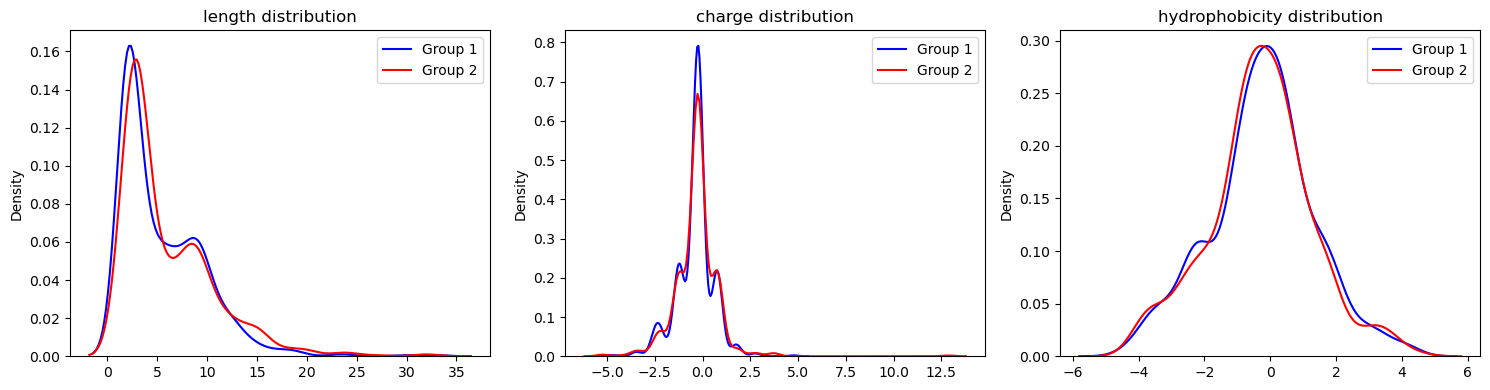

In [ ]:
# Visual inspection: positive/negative distributions should be close on key properties
sampler.get_distribution_diff(["length", "charge", "hydrophobicity"], k_list=[1, 2])
sampler.visualize_distributions(plot_type="kde")

In [ ]:
# Check amino-acid level distribution differences
res = sampler.get_distribution_diff(["length", "charge", "hydrophobicity"], k_list=[1, 2])
res

,property,mean_diff,js_divergence,ks_stat,ks_pvalue,q25_diff,q50_diff,q75_diff,n_group1,n_group2
0,length,-0.552050,0.105274,0.208202,1.937864e-12,-1.0000,0.000000,-1.00,634,634
1,charge,-0.059058,0.088139,0.061514,1.815429e-01,0.0000,0.000000,0.00,634,634
2,hydrophobicity,0.045642,0.100870,0.037855,7.544159e-01,0.0425,0.093155,0.05,634,634
3,1mer_js,NaN,0.025694,NaN,NaN,NaN,NaN,NaN,634,634
4,2mer_js,NaN,0.122063,NaN,NaN,NaN,NaN,NaN,634,634


In [5]:
import os
import pandas as pd


def merge_sequences_to_dataframe(pos, neg, save_path=None):
    """Merge positive and negative sequences into a labeled DataFrame.

    Args:
        pos (list[str]): Positive sequence list.
        neg (list[str]): Negative sequence list.
        save_path (str | None): Optional CSV output path.

    Returns:
        pd.DataFrame: Columns are `sequence` and `label` (1 for positive, 0 for negative).
    """
    if not all(isinstance(s, str) for s in pos + neg):
        raise ValueError("All sequences must be strings.")

    df = pd.DataFrame({
        "sequence": pos + neg,
        "label": [1] * len(pos) + [0] * len(neg),
    })

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved {len(df)} sequences to {save_path}")

    return df

In [6]:
# Merge positive and selected negative samples and save to disk
merge_sequences_to_dataframe(pos_seq, negatives_best, f"./{dataset_name}/all.csv")

NameError: name 'negatives_best' is not defined